# 多模型建模和性能对比#

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 导入数据

In [ ]:
import pandas as pd
train = pd.read_excel("train1.xlsx")
test = pd.read_excel("test1.xlsx")
# 划分特征和目标变量
x_train = train.drop(['Group'], axis=1)
y_train = train['Group']
x_val = test.drop(['Group'], axis=1)
y_val = test['Group']
# 划分特征和目标变量
#X = df.drop(['Group'], axis=1)
#y = df['Group']
# 划分训练集和测试集
#x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.3, 
#                                                     random_state=43, stratify=df['Group'])
#df.head()


# 模型调参参数设置

In [ ]:
# Define pipelines for individual models
model_pipelines = {
    'rf': Pipeline([('rf', RandomForestClassifier())]),
    'lr': Pipeline([('lr', LogisticRegression())]),
    'gbdt': Pipeline([('gbdt', GradientBoostingClassifier())]),
    'ada': Pipeline([('ada', AdaBoostClassifier())]),
    'xgb': Pipeline([('xgb', XGBClassifier())]),
    'lgbm': Pipeline([('lgbm', lgb.LGBMClassifier())]),
}

param_grids = {
    'rf': {  # Random Forest
        'rf__max_depth': [1, 2],
        'rf__n_estimators': [30, 50, 80],
        'rf__min_samples_split': [40, 60],
        'rf__min_samples_leaf': [10, 20],
        'rf__max_features': ['sqrt'],
    },

    'lr': {
    },

    'gbdt': {  # Gradient Boosting Classifier
        'gbdt__n_estimators': [30, 50, 80],
        'gbdt__learning_rate': [0.01, 0.05],
        'gbdt__max_depth': [1, 2],
        'gbdt__min_samples_split': [50, 80],
        'gbdt__min_samples_leaf': [20, 40],
        'gbdt__subsample': [0.4, 0.5, 0.6],
    },

    'ada': {  # AdaBoost Classifier
        'ada__n_estimators': [30, 50, 80],
        'ada__learning_rate': [0.005, 0.01, 0.05],
    },

    'xgb': {  # XGBoost
        'xgb__n_estimators': [30, 50, 100, 200],
        'xgb__max_depth': [1, 2, 3],
        'xgb__learning_rate': [0.01, 0.05],
        'xgb__subsample': [0.4, 0.5, 0.7],
        'xgb__colsample_bytree': [0.4, 0.5, 0.7],
        'xgb__reg_alpha': [1, 5, 10],
        'xgb__reg_lambda': [5, 10, 20],
    },

    'lgbm': {  # LightGBM
        'lgbm__n_estimators': [30, 50, 100, 200],
        'lgbm__max_depth': [2, 3],
        'lgbm__learning_rate': [0.01, 0.05],
        'lgbm__num_leaves': [4, 8],  # 关键：与 max_depth 匹配（2-><=4, 3-><=8）
        'lgbm__subsample': [0.4, 0.5, 0.7],
        'lgbm__colsample_bytree': [0.4, 0.5, 0.7],
        'lgbm__reg_alpha': [1, 5, 10],
        'lgbm__reg_lambda': [5, 10, 20],
    },
}



# 模型构建性能预测

In [ ]:
import os

os.makedirs("model", exist_ok=True)

# 假设 model_pipelines 和 param_grids 已经定义
results = {}
roc_curves = {}
calibration_curves = {}
dca_curves = {}

# 用于存储 y_train + y_train_proba 和 y_val + y_val_proba
train_results = {}
val_results = {}

for model_name, pipeline in model_pipelines.items():
    print(f"Optimizing model: {model_name}")
    param_grid = param_grids[model_name]
    random_search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=50,
        verbose=1,
        cv=5,
        n_jobs=-1,
        scoring='roc_auc'
    )
    random_search.fit(x_train, y_train)
    
    # 获取最佳模型
    best_model = random_search.best_estimator_
    
    # 保存模型为 .pkl 文件
    model_filename = os.path.join("model", f"{model_name}_best_model.pkl")
    joblib.dump(best_model, model_filename)
    print(f"Saved best model for {model_name} to {model_filename}")
    
    # 预测概率
    y_train_proba = best_model.predict_proba(x_train)[:, 1]
    y_val_proba = best_model.predict_proba(x_val)[:, 1]

    # 存储 y_train + y_train_proba 和 y_val + y_val_proba
    train_results[model_name] = pd.DataFrame({
        'y_train': y_train,
        'y_train_proba': y_train_proba
    })
    val_results[model_name] = pd.DataFrame({
        'y_val': y_val,
        'y_val_proba': y_val_proba
    })

    # ROC 数据
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)

    roc_curves[model_name] = {
        'train': (fpr_train, tpr_train, roc_auc_score(y_train, y_train_proba)),
        'val': (fpr_val, tpr_val, roc_auc_score(y_val, y_val_proba))
    }

    # 校准数据
    prob_true_train, prob_pred_train = calibration_curve(y_train, y_train_proba, n_bins=10)
    prob_true_val, prob_pred_val = calibration_curve(y_val, y_val_proba, n_bins=10)

    calibration_curves[model_name] = {
        'train': (prob_true_train, prob_pred_train),
        'val': (prob_true_val, prob_pred_val)
    }

    # DCA 数据
    thresholds = np.linspace(0.01, 0.99, 100)
    net_benefit_train = []
    net_benefit_val = []
    for t in thresholds:
        train_decisions = (y_train_proba >= t).astype(int)
        val_decisions = (y_val_proba >= t).astype(int)
        net_benefit_train.append(np.mean((train_decisions == y_train) * (y_train_proba - t) - (train_decisions != y_train) * t))
        net_benefit_val.append(np.mean((val_decisions == y_val) * (y_val_proba - t) - (val_decisions != y_val) * t))

    dca_curves[model_name] = {
        'train': (thresholds, net_benefit_train),
        'val': (thresholds, net_benefit_val)
    }

    # 存储最佳参数和 AUC
    auc_val = roc_auc_score(y_val, y_val_proba)
    results[model_name] = {
        'best_params': random_search.best_params_,
        'auc': auc_val
    }

# 打印所有结果
for model, result in results.items():
    print(f"Model: {model}, AUC: {result['auc']}, Best Params: {result['best_params']}")

# 导出 y_train + y_train_proba 和 y_val + y_val_proba
for model_name, df in train_results.items():
    df.to_csv(f"{model_name}_train_results.csv", index=False)
for model_name, df in val_results.items():
    df.to_csv(f"{model_name}_val_results.csv", index=False)

In [ ]:
# 创建一个DataFrame来存储所有模型的预测概率
# 第一列是真实标签（y_train 或 y_val），其他列是每个模型的预测概率
all_train_results = pd.DataFrame({'y_train': y_train})
all_val_results = pd.DataFrame({'y_val': y_val})

# 将每个模型的预测概率添加到DataFrame中
for model_name, df in train_results.items():
    all_train_results[f'{model_name}_proba'] = df['y_train_proba']

for model_name, df in val_results.items():
    all_val_results[f'{model_name}_proba'] = df['y_val_proba']

# 导出合并后的DataFrame到CSV文件
all_train_results.to_csv("all_train_results.csv", index=False)
all_val_results.to_csv("all_val_results.csv", index=False)

print("All train results have been saved to 'all_train_results.csv'")
print("All validation results have been saved to 'all_val_results.csv'")

# ROC绘制

In [ ]:
# Plot ROC curves for train and validation sets
plt.figure(figsize=(12, 6))

# Train set ROC curves
plt.subplot(1, 2, 1)
for model_name, curves in roc_curves.items():
    fpr, tpr, auc = curves['train']
    plt.plot(fpr, tpr, label=f"{model_name} (Train, AUC={auc:.3f})")
plt.title("ROC Curve - Train Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

# Validation set ROC curves
plt.subplot(1, 2, 2)
for model_name, curves in roc_curves.items():
    fpr, tpr, auc = curves['val']
    plt.plot(fpr, tpr, label=f"{model_name} (Validation, AUC={auc:.3f})")
plt.title("ROC Curve - Validation Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.savefig("roc_curves_with_auc.pdf")
plt.show()

# shap
----

In [ ]:
from sklearn.pipeline import Pipeline
model_path = r"model/rf_best_model.pkl"  # 使用原始字符串（raw string）避免转义问题
rf_model = joblib.load(model_path)

if isinstance(rf_model, Pipeline):
    # 打印 Pipeline 的步骤
    print(rf_model.named_steps)

In [ ]:
rb_estimator = rf_model.named_steps['rf']

In [33]:
import shap

# 创建 SHAP 解释器
explainer = shap.TreeExplainer(rb_estimator, x_train,
    feature_dependence="independent")

# 计算 SHAP 值
shap_values_numpy = explainer.shap_values(x_train)

# 可视化 SHAP 值（可选）
plt.figure()
shap.summary_plot(shap_values_numpy[1], x_train, feature_names=x_train.columns, plot_type="dot", show=False)
plt.savefig("SHAP_numpy summary_plot.pdf", format='pdf',bbox_inches='tight')

feature_dependence = "independent" has been renamed to feature_perturbation = "interventional"! See GitHub issue #882.


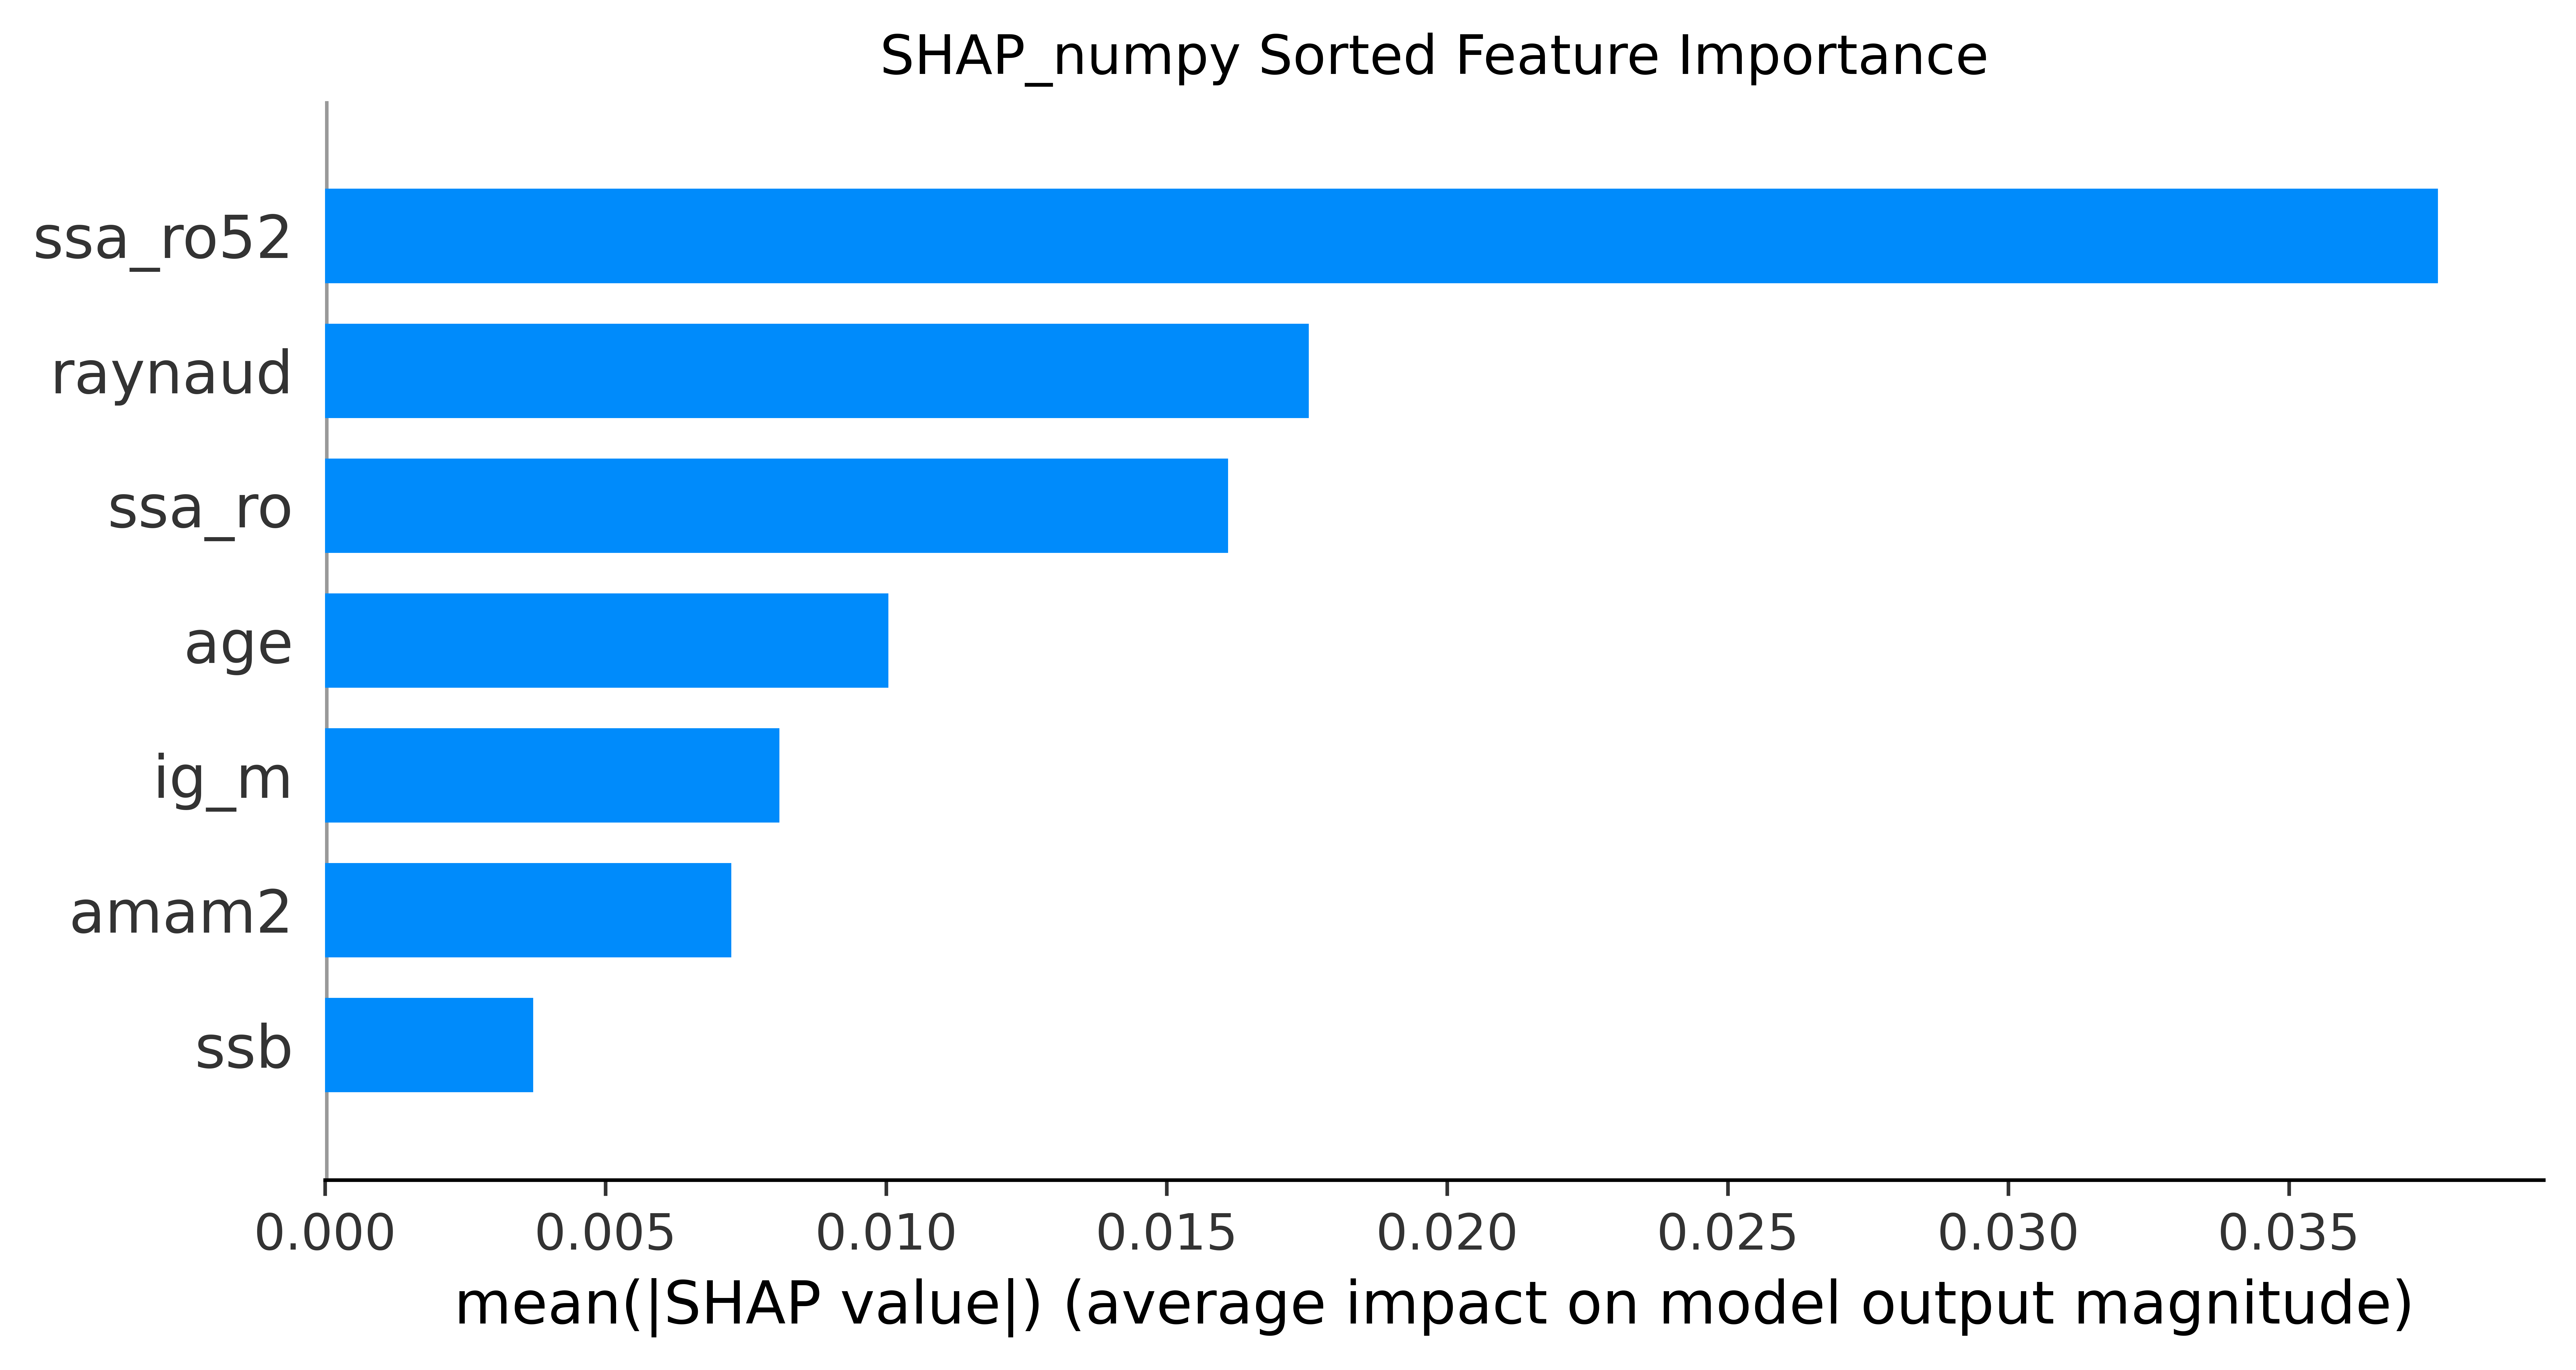

In [32]:
plt.figure(figsize=(10, 5), dpi=1200)
shap.summary_plot(shap_values_numpy[1], x_train, plot_type="bar", show=False)
plt.title('SHAP_numpy Sorted Feature Importance')
plt.tight_layout()
plt.savefig("SHAP_numpy Sorted Feature Importance.pdf", format='pdf',bbox_inches='tight')
plt.show()

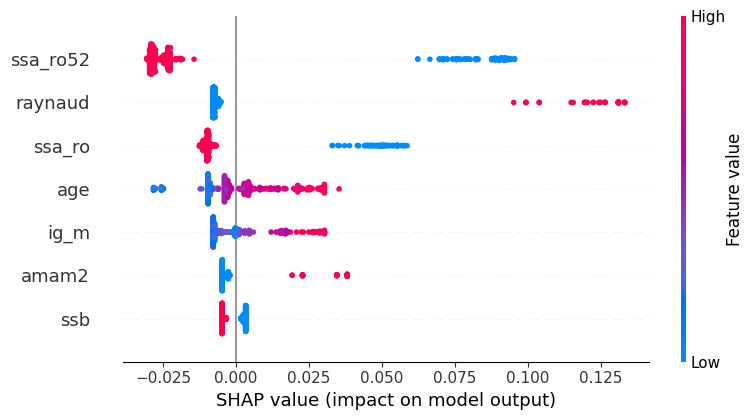

In [35]:
# 创建主图（用来画蜂巢图）
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=1200)
# 在主图上绘制蜂巢图，并保留热度条
shap.summary_plot(shap_values_numpy[1], x_train, feature_names=x_train.columns, plot_type="dot", show=False, color_bar=True)
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 调整图表位置，留出右侧空间放热度条
# 获取共享的 y 轴
ax1 = plt.gca()
# 创建共享 y 轴的另一个图，绘制特征贡献图在顶部x轴
ax2 = ax1.twiny()
shap.summary_plot(shap_values_numpy[1], x_train, plot_type="bar", show=False)
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 调整图表位置，与蜂巢图对齐
# 在顶部 X 轴添加一条横线
ax2.axhline(y=13, color='gray', linestyle='-', linewidth=1)  # 注意y值应该对应顶部
# 调整透明度
bars = ax2.patches  # 获取所有的柱状图对象
for bar in bars:
    bar.set_alpha(0.2)  # 设置透明度
# 设置两个x轴的标签
ax1.set_xlabel('Shapley Value Contribution (Bee Swarm)', fontsize=12)
ax2.set_xlabel('Mean Shapley Value (Feature Importance)', fontsize=12)
# 移动顶部的 X 轴，避免与底部 X 轴重叠
ax2.xaxis.set_label_position('top')  # 将标签移动到顶部
ax2.xaxis.tick_top()  # 将刻度也移动到顶部
# 设置y轴标签
ax1.set_ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig("SHAP_combined_with_top_line_corrected.pdf", format='pdf', bbox_inches='tight')
plt.show()

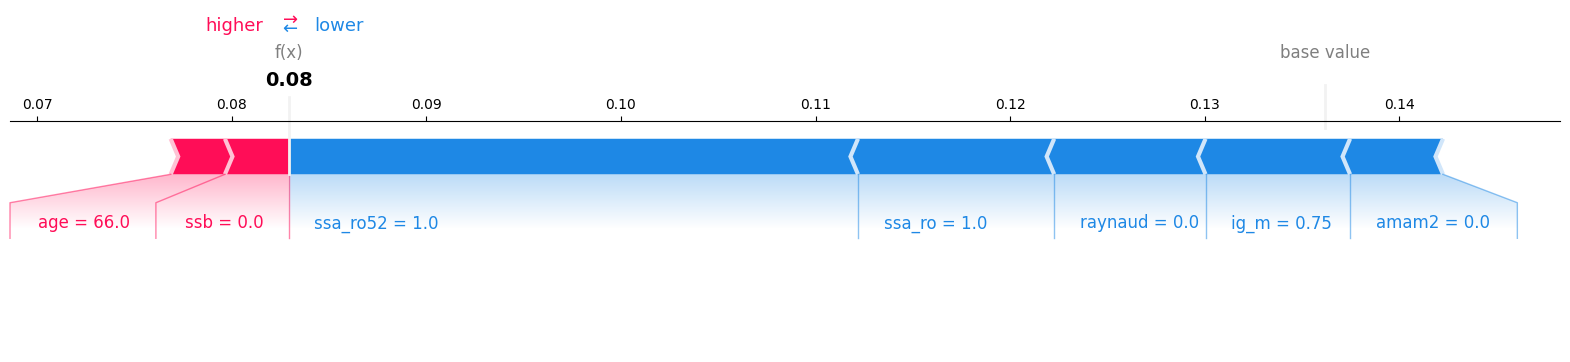

In [39]:
class_idx = 1     # 你要解释的类别（与 shap_values_numpy[1] 对齐）
i = 0             # 你要解释的样本索引（与 x_train.iloc[0] 对齐）

# 1) base_value 必须是标量：取对应类别的 expected_value
ev = explainer.expected_value
base_value = ev[class_idx] if np.ndim(ev) > 0 else ev

# 2) 取对应类别、对应样本的 shap 向量 (n_features,)
sv = shap_values_numpy[class_idx][i]      # 等价于 shap_values_explanation.values[i]

# 3) 取对应样本特征（Series）
x = x_train.iloc[i, :]

# 4) force plot + 保存
shap.plots.force(base_value, sv, x, matplotlib=True, show=False)
plt.savefig("force_plot1.pdf", bbox_inches="tight")
plt.close()
shap.plots.force(base_value, sv, x, matplotlib=True, show=False)

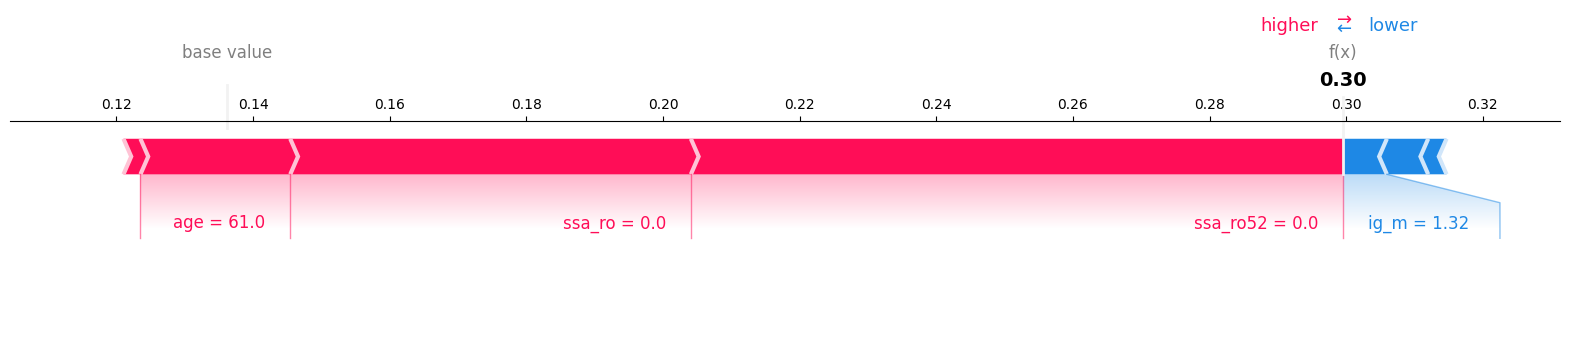

In [40]:
class_idx = 1     # 你要解释的类别（与 shap_values_numpy[1] 对齐）
i = 235             # 你要解释的样本索引（与 x_train.iloc[0] 对齐）

# 1) base_value 必须是标量：取对应类别的 expected_value
ev = explainer.expected_value
base_value = ev[class_idx] if np.ndim(ev) > 0 else ev

# 2) 取对应类别、对应样本的 shap 向量 (n_features,)
sv = shap_values_numpy[class_idx][i]      # 等价于 shap_values_explanation.values[i]

# 3) 取对应样本特征（Series）
x = x_train.iloc[i, :]

# 4) force plot + 保存
shap.plots.force(base_value, sv, x, matplotlib=True, show=False)
plt.savefig("force_plot1.pdf", bbox_inches="tight")
plt.close()
shap.plots.force(base_value, sv, x, matplotlib=True, show=False)

In [41]:
import numpy as np
import shap

# —— 可配置参数 ——
class_idx = 1          # 多输出模型时选择的输出（如二分类的正类），单输出可忽略
max_samples = 270      # 为避免HTML过大，最多展示的样本数（按行顺序截取）
html_path = "force_plot_multi.html"

# —— 构建 Explanation（你已有 shap_values_explanation 可跳过本段）——
# 假设：shap_values_numpy 形状为 [n_outputs, n_samples, n_features]（或等价列表）
#       x_train 为 pandas.DataFrame
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[class_idx]
    shap_values = shap_values_numpy[class_idx]
else:
    base_value = explainer.expected_value
    shap_values = shap_values_numpy

n = min(max_samples, shap_values.shape[0])
exp_multi = shap.Explanation(
    values=shap_values[:n],
    base_values=np.full(n, base_value),
    data=x_train.iloc[:n, :].values,
    feature_names=x_train.columns.tolist()
)

# —— 生成交互式 force plot 并保存为 HTML ——
plot = shap.plots.force(
    exp_multi,          # 直接传 Explanation（新版API）
    show=False          # 不在当前会话内直接显示
)
shap.save_html(html_path, plot)

print(f"Saved: {html_path}")

Saved: force_plot_multi.html
